# Telecom Churn Prediction – Logistic Regression Baseline

Goals:
- Load the preprocessed dataset.
- Split the data into training and testing sets.
- Train a Logistic Regression baseline model.
- Evaluate model performance using classification metrics.
- Analyze model coefficients to understand feature impact.

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

sns.set_style("whitegrid")

In [95]:
df = pd.read_csv("../../data/processed/telecom_churn_clean.csv")

df.head()

,tenure,MonthlyCharges,Churn,num_services,gender_Male,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,charge_level_medium,charge_level_high,tenure_group_early,tenure_group_established,tenure_group_loyal
0,-1.277445,-1.160323,0,-0.561776,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
1,0.066327,-0.259629,0,-0.020519,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False
2,-1.236724,-0.362660,1,-0.020519,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False
3,0.514251,-0.746535,0,0.520738,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
4,-1.236724,0.197365,1,-1.103033,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,False


In [96]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 20)


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   float64
 1   MonthlyCharges                         7043 non-null   float64
 2   Churn                                  7043 non-null   int64  
 3   num_services                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Dependents_Yes                         7043 non-null   bool   
 6   PhoneService_Yes                       7043 non-null   bool   
 7   InternetService_Fiber optic            7043 non-null   bool   
 8   InternetService_No                     7043 non-null   bool   
 9   Contract_One year                      7043 non-null   bool   
 10  Contract_Two year                      7043 non-null   bool   
 11  PaperlessBillin

In [98]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (7043, 19)
Target shape: (7043,)


In [99]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 19)
Test size: (1409, 19)


In [100]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [101]:
log_model = LogisticRegression(max_iter=1000, random_state=42 , class_weight="balanced") #class_weight="balanced" handle class imbalance..

# Hyperparameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

# Grid Search
grid_search_log = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search_log.fit(X_train, y_train)

# Best model
best_log_model = grid_search_log.best_estimator_

print("Best Parameters:", grid_search_log.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/home/rehobot/Documents/Projects/telecom-churn-prediction-platform/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/rehobot/Documents/Projects/telecom-churn-prediction-platform/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/rehobot/Documents/Projects/telecom-churn-prediction-platform/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to 

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


/home/rehobot/Documents/Projects/telecom-churn-prediction-platform/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [102]:
y_pred_test = best_log_model.predict(X_test)
y_prob_test = best_log_model.predict_proba(X_test)[:, 1]

y_pred_train=best_log_model.predict(X_train)
y_prob_train=best_log_model.predict_proba(X_train)[:, 1]

In [103]:
#Accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Test Accuracy:", test_accuracy)
print("Train Accuracy:", train_accuracy)

Test Accuracy: 0.7352732434350603
Train Accuracy: 0.7492012779552716


In [104]:
#Classification Report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.74      0.75      1409



In [105]:
#ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob_test)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8409452582086853


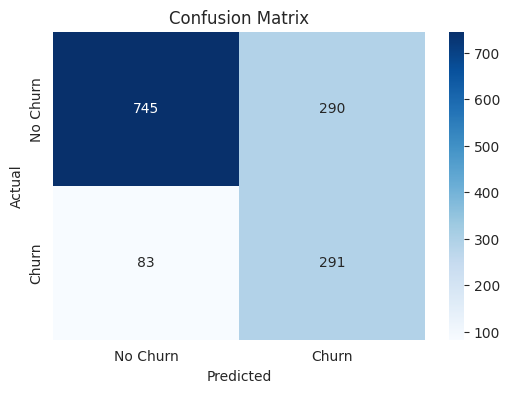

In [106]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

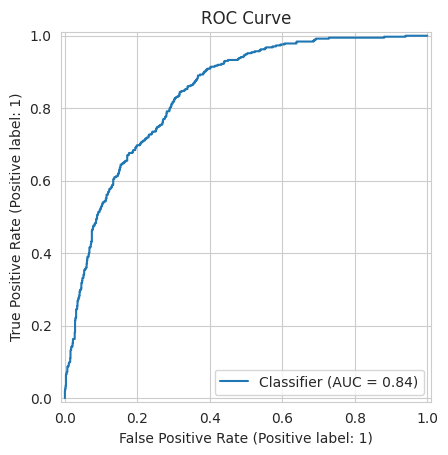

In [107]:
#ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_test)

plt.title("ROC Curve")
plt.show()

In [108]:
#Model Coefficients (Feature Importance)
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": best_log_model.coef_[0]
})

coefficients = coefficients.sort_values(by="coefficient", ascending=False)

coefficients.head(10)

,feature,coefficient
1,MonthlyCharges,2.218043
7,InternetService_No,1.124309
12,PaymentMethod_Electronic check,0.437120
10,PaperlessBilling_Yes,0.380074
18,tenure_group_loyal,0.361689
13,PaymentMethod_Mailed check,0.048432
3,gender_Male,0.039684
11,PaymentMethod_Credit card (automatic),0.019131
14,charge_level_medium,0.018276
15,charge_level_high,-0.060088


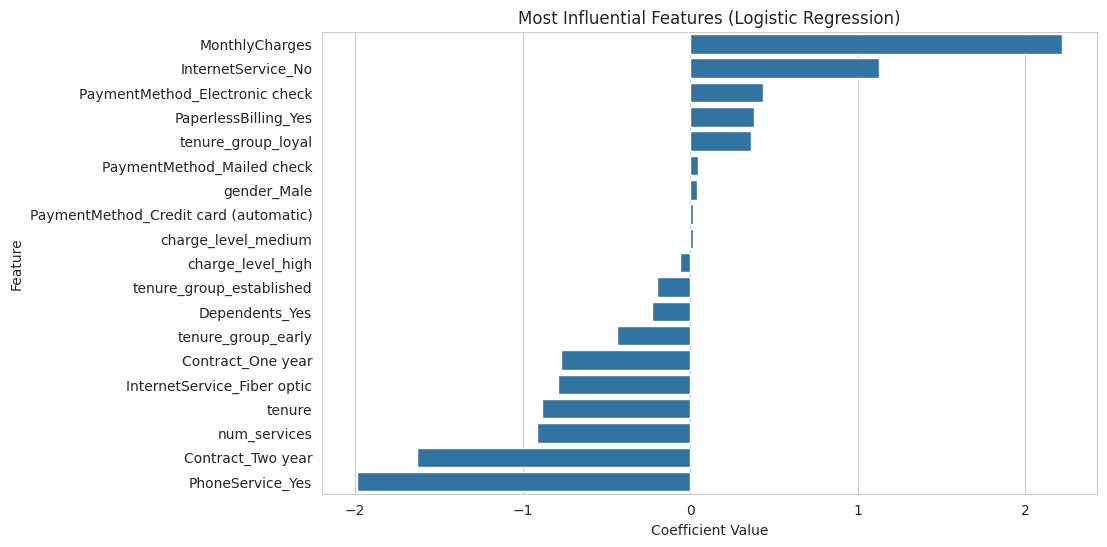

In [109]:
#Plot Most Important Features
top_positive = coefficients.head(10)
top_negative = coefficients.tail(10)

important_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10,6))

sns.barplot(
    x="coefficient",
    y="feature",
    data=important_features
)

plt.title("Most Influential Features (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [110]:
import joblib

joblib.dump(best_log_model, "../models/logistic_regression_baseline.pkl")

['../models/logistic_regression_baseline.pkl']